## Plot Error Gains in Bar Plot: Varying Thresholds

In [56]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

from fontTools.misc import psOperators

from design_elements.color_palette import get_histogram_colors
from design_elements.set_of_markers import get_markers
from experiments_acs.aggregation_refinement.plot.plot_refinement_thresholds import process_logs
from experiments_acs.aggregation_refinement.plot_normalized_gain_lines.normalized_bootstrap import \
    bootstrap_normalized_error_gains
from file_logging.read_and_write_json import save_as_json
from utility.plot_style import set_plot_style
from utility.directories import get_plot_dir

In [57]:
# Plot directory
plot_base_dir = get_plot_dir()
plot_dir = plot_base_dir / "aggregation_relative_gain_bars"
plot_dir.mkdir(parents=True, exist_ok=True)

# Set style
set_plot_style(sans_serif=False, factor=1.225)

# Line width
plt.rcParams.update({
    "axes.linewidth": 2,
    "grid.linewidth": 1.75,
})

# Load experiment logs
with open("./../plot/experiments_refinement_threshold_gt_priors.yaml", "r") as f:
    logs = yaml.safe_load(f)

# Toggle to use new jointly elicited priors
load_joint_llm_priors = False

# Process results
results, experiment_name = process_logs(logs=logs,
                                        overwrite_cluster_to_false=False,
                                        load_joint_llm_priors=load_joint_llm_priors)

# Filename
filename = f"thresholds_{"llm_prior" if load_joint_llm_priors else "gt_prior"}.json"

# Save results to JSON file
results_path = save_as_json(
    data=results,
    experiment="figure_aggregation_relative_gain",
    filename=filename,
    timestamp=False)
print(f"\nResults saved to {results_path}")

# Remove some entries
masked_refinement_res = []
for entry in results["refinement_results"]:
    if entry["income_threshold"] == 100_000:
        continue
    else:
        masked_refinement_res.append(entry)
results["refinement_results"] = masked_refinement_res

Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
Done!
Found 5 level files: ['level_0.json', 'level_1.json', 'level_2.json', 'level_3.json', 'level_4.json']
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
  ----> Using ground-truth priors
Done!
Found 5 level file

/Users/patrikwolf/code/incontext_learning/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/patrikwolf/code/incontext_learning/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


#### Plotting

In [58]:
def format_threshold_short(tau):
    if tau >= 1000:
        return rf"${tau // 1000}\mathrm{{k}}$"
    return rf"${tau}$"

In [59]:
def add_threshold_annotation(x_pos, y_mean, y_lower, y_upper, threshold_short_labels):
    for xp, y, yl, yu in zip(x_pos, y_mean, y_lower, y_upper):
        if y >= 0:
            y_text = yu
            va = "bottom"
            offset = 4
        else:
            y_text = yl
            va = "top"
            offset = -4

        plt.annotate(
            threshold_short_labels[i],
            xy=(xp, y_text),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=8,
            rotation=90,
            zorder=20,
        )

In [60]:
# Title
title = (r"\textbf{Estimation Error}"
         "\n"
         r"\normalsize "
         f"Model: {results['model']}, reasoning effort: '{results['reasoning_effort']}', "
         f"prompting scheme: '{results['prompting_scheme']}'"
         "\n"
         r"\normalsize "
         f"Loaded and used jointly elicited LLM priors: {load_joint_llm_priors}, "
         f"(individual LLM-estimated priors available: {results['llm_estimated_priors']})"
         "\n"
         r"\normalsize "
         f"Task: estimate the probability that an individual belonging to a subpopulation has an income "
         f"above a predefined threshold"
         "\n"
         r"\normalsize "
         f"Income thresholds (USD): {results['income_thresholds']}, Income above or below threshold: "
         f"{results['income_greater_than_threshold']}"
         "\n"
         r"\normalsize "
         f"Number of repetitions per setting: {results['num_of_samples']}"
         "\n\n")

In [61]:
# Initialization
values_by_level = defaultdict(list)
all_x = set()
all_results = []
threshold_labels = []

# First pass: compute all values
entries = results["refinement_results"]
for entry in entries:
    print(f"Processing entry for income threshold {entry['income_threshold']} USD...")

    x, y_mean, y_lower, y_upper = bootstrap_normalized_error_gains(refinement_results=entry["refinement_results"])
    all_x.update([int(level) for level in x])

    # Save in dict and list
    for level, mean in zip(x, y_mean):
        values_by_level[level].append(mean)

    all_results.append((x, y_mean, y_lower, y_upper))
    threshold_labels.append(r"$\tau = " + f"{entry['income_threshold']:,}$ USD".replace(",", r"\,"))

Processing entry for income threshold 100 USD...
Processing entry for income threshold 1000 USD...
Processing entry for income threshold 10000 USD...
Processing entry for income threshold 20000 USD...
Processing entry for income threshold 40000 USD...
Processing entry for income threshold 60000 USD...
Processing entry for income threshold 80000 USD...


[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
[1, 2, 3, 4]
[-0.3 -0.2 -0.1  0.   0.1  0.2  0.3]


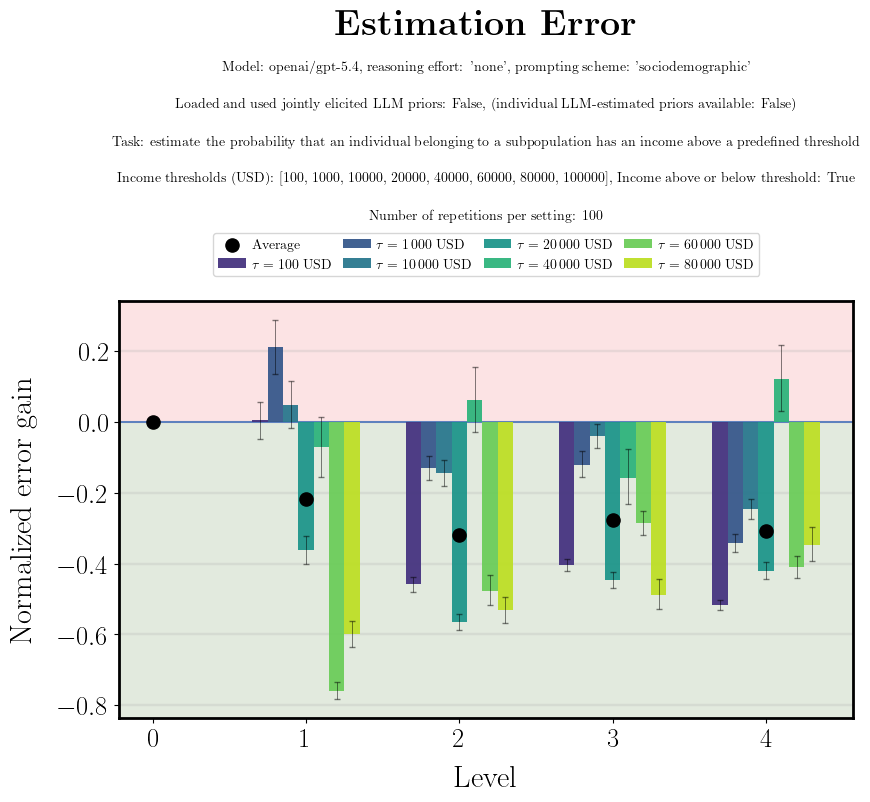

In [62]:
# Plot size
plt.figure(figsize=(9, 8.4))

# Colormap
colors = get_histogram_colors(llm=True, num_colors=len(entries))
markers, marker_sizes = get_markers(num_markers=len(entries))

# Colors
positive_color = "#F2545B"   # red
negative_color = "#4E7D32"   # green

# Levels
x_levels = np.array(sorted(all_x))
num_levels = len(x_levels)
num_entries = len(entries)

# Grouped bar layout
bar_width = 0.10
group_width = num_entries * bar_width
offsets = np.linspace(
    -group_width / 2 + bar_width / 2,
    group_width / 2 - bar_width / 2,
    num_entries
)

# Plot bars
for i, (x, y_mean, y_lower, y_upper) in enumerate(all_results):
    # Truncate first
    x = x[1:]
    y_mean = y_mean[1:]
    y_lower = y_lower[1:]
    y_upper = y_upper[1:]

    print(x)
    print(offsets)

    # Compute x, y arrays and error bars
    x_pos = x + offsets[i]
    # bar_colors = [positive_color if y >= 0 else negative_color for y in y_mean]
    yerr = np.vstack([y_mean - np.asarray(y_lower), np.asarray(y_upper) - y_mean])

    # Bar plot
    plt.bar(
        x_pos,
        y_mean,
        width=bar_width,
        color=colors[i],
        alpha=0.95,
        zorder=3,
        label=threshold_labels[i],
    )

    # Error bars
    plt.errorbar(
        x_pos,
        y_mean,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.7,
        capsize=2,
        alpha=0.5,
        zorder=4,
    )

    # Threshold annotations
    # threshold_short_labels = [format_threshold_short(entry["income_threshold"]) for entry in entries]
    # add_threshold_annotation(x_pos, y_mean, y_lower, y_upper, threshold_short_labels)

# Compute average trend
x_avg = sorted(values_by_level.keys())
y_avg = [np.mean(values_by_level[level]) for level in x_avg]

# Plot average as black dots
plt.scatter(
    x_avg,
    y_avg,
    color="black",
    s=90,
    zorder=10,
    label="Average",
)

# Get axes
ax = plt.gca()

# Get current axis limits after plotting the data
ymin, ymax = ax.get_ylim()

# Make sure zero is included
ymin = min(ymin, 0)
ymax = max(ymax, 0)

# Green region below y = 0
ax.axhspan(
    ymin,
    0,
    facecolor=negative_color,
    alpha=0.16,
    zorder=-10,
)

# Red/orange region above y = 0
ax.axhspan(
    0,
    ymax,
    facecolor=positive_color,
    alpha=0.16,
    zorder=-10,
)

# Zero line on top
ax.axhline(0, color="#3F6FC4", lw=1.2, zorder=1)

# Zero line
plt.axhline(0, color="#3F6FC4", lw=1.2, zorder=1)

# Formatting
plt.title(title)
plt.xlabel("Level", labelpad=10)
plt.ylabel("Normalized error gain", labelpad=15)
plt.xticks(x_levels, [f"{level}" for level in x_levels])
ax.set_ylim(ymin, ymax)
plt.grid(axis="y", alpha=0.25, zorder=0)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    prop={"size": 10},
    columnspacing=0.8,
    handletextpad=0.4,
)
plt.tight_layout()

# Add prior to plot name
prior_usage = "llm_prior" if load_joint_llm_priors else "gt_prior"

# Save plot
plot_subdir = plot_dir / prior_usage
plot_subdir.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_subdir / f"threshold_{experiment_name}.png", dpi=300)
plt.savefig(plot_subdir / f"threshold_{experiment_name}.pdf")

# Show plot
plt.show()